In [1]:
# import the libraries I'll need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# get my data file path and save it as a variable
data_file = '/Users/ryaneagan/Downloads/Monthly_Temperature_Update2(1).xls'

In [4]:
# Read the whole sheet without headers
df_raw = pd.read_excel(data_file, header=None)

In [5]:
# Utility to deduplicate column names like ['Jan', 'Jan'] -> ['Jan', 'Jan.1']
def deduplicate_columns(columns):
    seen = {}
    result = []
    for col in columns:
        if col not in seen:
            seen[col] = 0
            result.append(col)
        else:
            seen[col] += 1
            result.append(f"{col}.{seen[col]}")
    return result

all_data = []
i = 0
shared_header = None

while i < len(df_raw):
    # Skip blank rows
    while i < len(df_raw) and df_raw.iloc[i].isna().all():
        i += 1

    if i >= len(df_raw): break

    # Step 2: Group name row
    group_row = df_raw.iloc[i]
    group_name = "_".join(group_row.dropna().astype(str).str.strip())
    i += 1

    if i >= len(df_raw): break

    # Step 3: Header row
    header_row = df_raw.iloc[i].astype(str).fillna("").str.strip().tolist()
    if shared_header is None:
        shared_header = deduplicate_columns(header_row)  # Save only the first header and fix dups
    i += 1

    # Step 4: Data rows
    data_rows = []
    while i < len(df_raw) and not df_raw.iloc[i].isna().all():
        data_rows.append(df_raw.iloc[i])
        i += 1

    if data_rows:
        block = pd.DataFrame(data_rows, columns=df_raw.columns)
        block.columns = shared_header  # Apply consistent shared header
        block["Group"] = group_name
        all_data.append(block)

# Step 5: Combine everything
df_combined = pd.concat(all_data, ignore_index=True)

# Step 6: Optional numeric conversion
for col in df_combined.columns:
    if col not in ["Lat", "Lon", "Group"]:
        df_combined[col] = pd.to_numeric(df_combined[col], errors="ignore")

/var/folders/hg/by60chbx3gv__xtd5c1p9sxm0000gn/T/ipykernel_86204/1790044182.py:56: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_combined[col] = pd.to_numeric(df_combined[col], errors="ignore")


In [6]:
df_combined

,Station,Lat,Lon,Lat_num,Lon_num,Elev,Jan,Feb,Mar,Apr,...,Jul,Aug,Sep,Oct,Nov,Dec,nan,nan.1,nan.2,Group
0,10050,78.1N,13.6E,78.1,13.6,9.0,-12.3,-13.4,-14.4,-10.7,...,5.1,4.6,0.8,-4.2,-8.2,-10.5,NaN,NaN,NaN,Arctic
1,200460,80.6N,58.1E,80.6,58.1,20.0,-25.0,-25.3,-24.8,-19.9,...,0.8,-0.1,-3.2,-11.8,-19.3,-23.3,NaN,NaN,NaN,Arctic
2,206740,73.5N,80.2E,73.5,80.2,20.0,-25.4,-25.5,-24.1,-17.5,...,4.6,5.0,1.5,-7.5,-17.6,-22.3,NaN,NaN,NaN,Arctic
3,202920,77.7N,104.3E,77.7,104.3,13.0,-29.0,-29.4,-28.3,-21.1,...,1.4,0.6,-2.6,-13.2,-22.4,-26.2,NaN,NaN,NaN,Arctic
4,214320,76.0N,137.9E,76.0,137.9,10.0,-30.2,-30.7,-28.0,-21.2,...,2.5,1.7,-1.7,-12.3,-23.0,-27.6,NaN,NaN,NaN,Arctic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472,990100,52.5N,20.0W,52.5,-20.0,8.7,8.7,9.2,9.7,10.8,...,14.2,13.7,12.3,10.5,9.5,11.1,11.333333,NaN,NaN,Ocean_Weather_Ships
473,990110,45.0N,16.0W,45.0,-16.0,12.1,11.3,11.6,12.2,13.5,...,18.6,17.9,16.2,14.0,12.7,14.4,14.641667,NaN,NaN,Ocean_Weather_Ships
474,990130,66.0N,2.0E,66.0,2.0,3.6,3.2,3.4,4.3,6.2,...,10.9,9.7,7.3,5.5,4.0,6.4,6.600000,NaN,NaN,Ocean_Weather_Ships
475,990140,30.0N,140.0W,30.0,-140.0,17.9,17.5,17.0,17.3,18.1,...,21.7,22.1,21.4,20.0,18.6,19.3,19.425000,NaN,NaN,Ocean_Weather_Ships


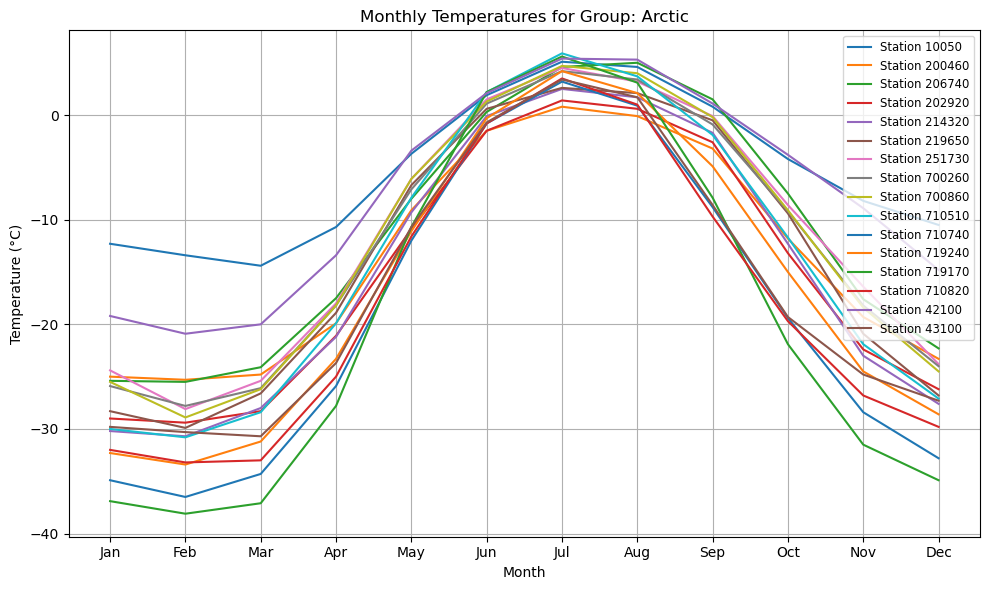

In [7]:
import matplotlib.pyplot as plt

# Step 1: Filter for one group (e.g., 'Arctic')
group_df = df_combined[df_combined['Group'] == 'Arctic']

# Step 2: Select monthly columns
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_data = group_df[months]

# Step 3: Plot each station's monthly temps
plt.figure(figsize=(10, 6))

for index, row in monthly_data.iterrows():
    plt.plot(months, row.values, label=f"Station {group_df.loc[index, 'Station']}")

plt.title('Monthly Temperatures for Group: Arctic')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Step 1: Identify month columns
month_cols = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Step 2: Ensure they're numeric
df_combined[month_cols] = df_combined[month_cols].apply(pd.to_numeric, errors="coerce")

# Step 3: Compute the annual average
df_avg = df_combined.copy()
df_avg["AnnualAvg"] = df_avg[month_cols].mean(axis=1)

# Step 4: Select final columns
df_annual_avg = df_avg[["Station", "Group", "Lat_num", "Lon_num", "AnnualAvg"]].copy()

# Step 5: Drop duplicate station entries (if each station appears only once per dataset)
df_annual_avg = df_annual_avg.drop_duplicates(subset="Station").reset_index(drop=True)

In [9]:
df_annual_avg

,Station,Group,Lat_num,Lon_num,AnnualAvg
0,10050,Arctic,78.1,13.6,-5.416667
1,200460,Arctic,80.6,58.1,-13.541667
2,206740,Arctic,73.5,80.2,-11.375000
3,202920,Arctic,77.7,104.3,-15.216667
4,214320,Arctic,76.0,137.9,-14.991667
...,...,...,...,...,...
472,990100,Ocean_Weather_Ships,52.5,-20.0,11.333333
473,990110,Ocean_Weather_Ships,45.0,-16.0,14.641667
474,990130,Ocean_Weather_Ships,66.0,2.0,6.600000
475,990140,Ocean_Weather_Ships,30.0,-140.0,19.425000


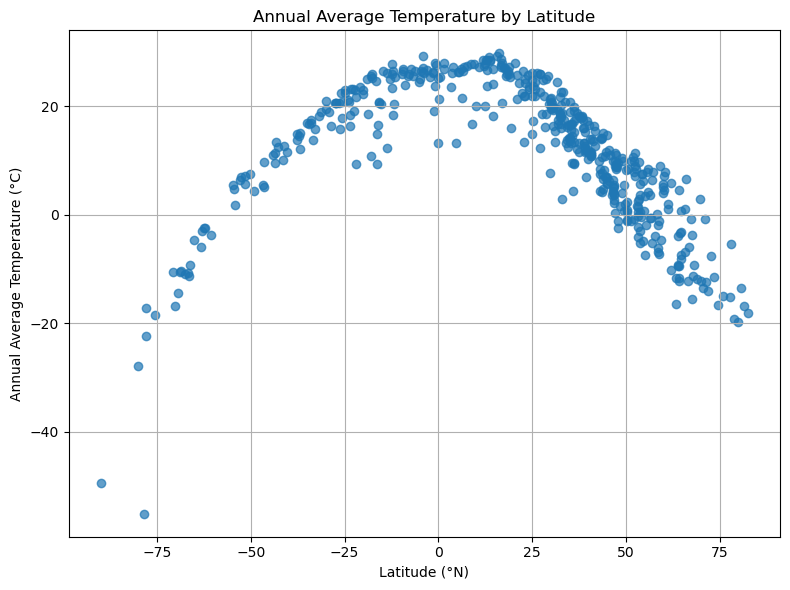

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df_annual_avg["Lat_num"], df_annual_avg["AnnualAvg"], alpha=0.7)

plt.xlabel("Latitude (°N)")
plt.ylabel("Annual Average Temperature (°C)")
plt.title("Annual Average Temperature by Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()

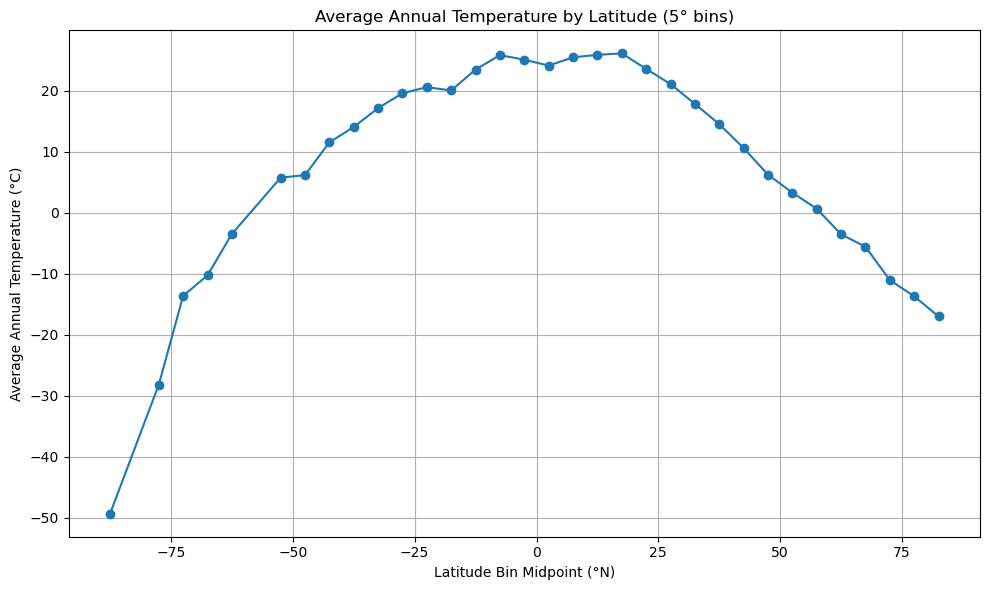

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Create latitude bins from -90 to 90
lat_bins = np.arange(-90, 95, 5)  # Includes final bin edge
df_annual_avg["LatBin"] = pd.cut(df_annual_avg["Lat_num"], bins=lat_bins, right=False)

# Step 2: Group by latitude bin and compute mean AnnualAvg
df_lat_binned = df_annual_avg.groupby("LatBin", observed=True)["AnnualAvg"].mean().reset_index()

# Step 3: Compute bin midpoints for plotting
df_lat_binned["LatBinMid"] = df_lat_binned["LatBin"].apply(lambda x: (x.left + x.right) / 2)

# Step 4: Plot
plt.figure(figsize=(10, 6))
plt.plot(df_lat_binned["LatBinMid"], df_lat_binned["AnnualAvg"], marker='o')

plt.xlabel("Latitude Bin Midpoint (°N)")
plt.ylabel("Average Annual Temperature (°C)")
plt.title("Average Annual Temperature by Latitude (5° bins)")
plt.grid(True)
plt.tight_layout()
plt.show()

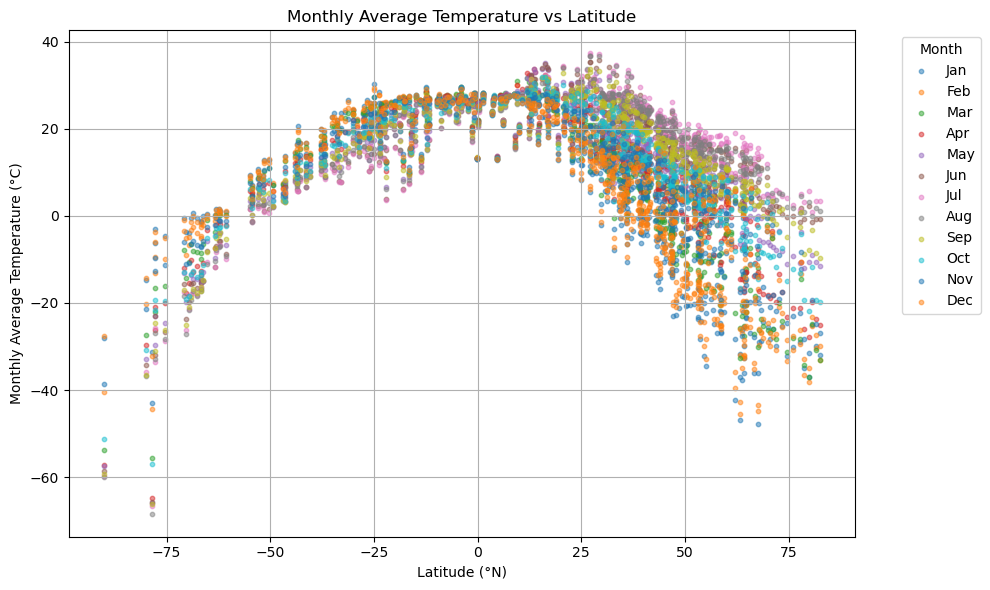

In [12]:
# Plots by Month


# Step 1: Melt df_combined to long format
df_long = df_combined.melt(
    id_vars=["Station", "Group", "Lat_num", "Lon_num"],
    value_vars=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    var_name="Month",
    value_name="Temperature"
)

# Step 2: Convert temperature to numeric (just in case)
df_long["Temperature"] = pd.to_numeric(df_long["Temperature"], errors="coerce")
df_long["Lat_num"] = pd.to_numeric(df_long["Lat_num"], errors="coerce")

# Step 3: Create scatter plot
plt.figure(figsize=(10, 6))
for month in df_long["Month"].unique():
    subset = df_long[df_long["Month"] == month]
    plt.scatter(subset["Lat_num"], subset["Temperature"], label=month, alpha=0.5, s=10)

plt.xlabel("Latitude (°N)")
plt.ylabel("Monthly Average Temperature (°C)")
plt.title("Monthly Average Temperature vs Latitude")
plt.legend(title="Month", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

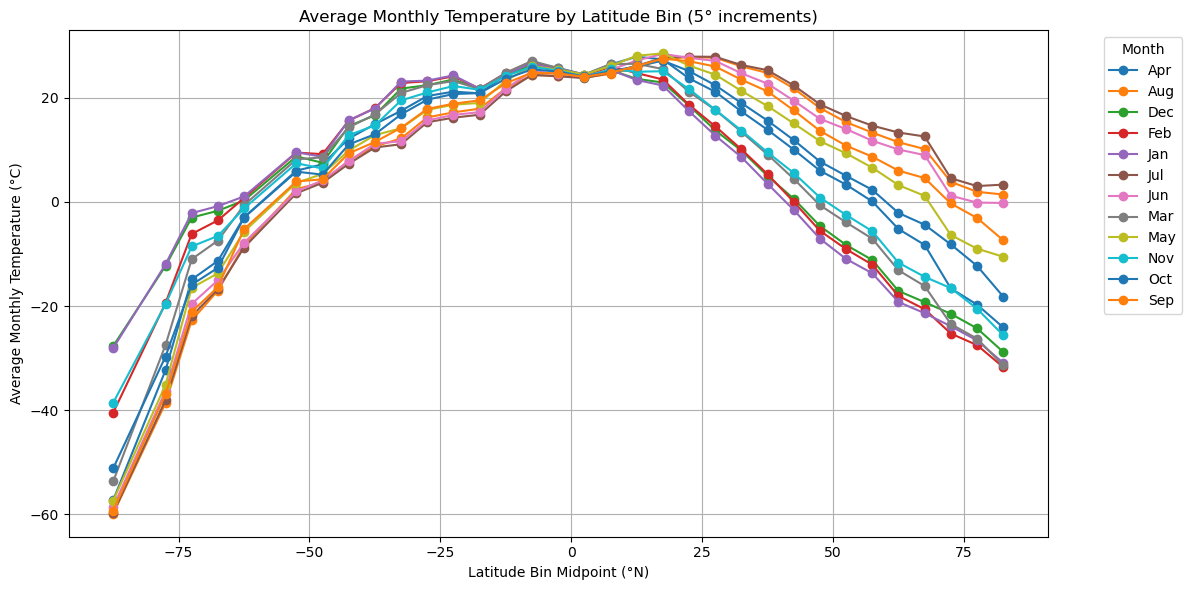

In [13]:
import numpy as np

# Step 1: Bin latitude from -90 to 90 in 5° increments
lat_bins = np.arange(-90, 95, 5)  # 95 so the last bin is [85, 90)
df_long["LatBin"] = pd.cut(df_long["Lat_num"], bins=lat_bins, right=False)

# Step 2: Compute mean temperature per bin per month
df_grouped = df_long.groupby(["LatBin", "Month"], observed=True)["Temperature"].mean().reset_index()

# Step 3: Compute bin midpoints for plotting
df_grouped["LatBinMid"] = df_grouped["LatBin"].apply(lambda x: (x.left + x.right) / 2)

# Step 4: Plot it
plt.figure(figsize=(12, 6))

for month in df_grouped["Month"].unique():
    subset = df_grouped[df_grouped["Month"] == month]
    plt.plot(subset["LatBinMid"], subset["Temperature"], label=month, marker="o")

plt.xlabel("Latitude Bin Midpoint (°N)")
plt.ylabel("Average Monthly Temperature (°C)")
plt.title("Average Monthly Temperature by Latitude Bin (5° increments)")
plt.legend(title="Month", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()